# Model Comparison and Selection

This notebook compares all machine learning models developed for customer churn prediction and selects the most suitable model for deployment based on predictive performance and business considerations.

## Objective

Five machine learning models have been developed:

- Logistic Regression
- Decision Tree
- Random Forest
- XGBoost
- CatBoost

The objective of this notebook is to compare these models using common evaluation metrics and recommend the most appropriate model for deployment.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
comparison = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost",
        "CatBoost"
    ],

    "Accuracy":[
        0.8010,
        0.7839,
        0.7932,
        0.7967,
        0.8017
    ],

    "Precision":[
        0.6442,
        0.5862,
        0.6436,
        0.6477,
        0.6599
    ],

    "Recall":[
        0.5615,
        0.6364,
        0.4973,
        0.5160,
        0.5241
    ],

    "F1":[
        0.6000,
        0.6103,
        0.5611,
        0.5744,
        0.5842
    ],

    "ROC_AUC":[
        0.8350,
        0.8221,
        0.8340,
        0.8411,
        0.8404
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.8010,0.6442,0.5615,0.6000,0.8350
1,Decision Tree,0.7839,0.5862,0.6364,0.6103,0.8221
2,Random Forest,0.7932,0.6436,0.4973,0.5611,0.8340
3,XGBoost,0.7967,0.6477,0.5160,0.5744,0.8411
4,CatBoost,0.8017,0.6599,0.5241,0.5842,0.8404


In [7]:
comparison.style.highlight_max(
    subset=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC_AUC"
    ],
    color="white"
)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.801000,0.644200,0.561500,0.600000,0.835000
1,Decision Tree,0.783900,0.586200,0.636400,0.610300,0.822100
2,Random Forest,0.793200,0.643600,0.497300,0.561100,0.834000
3,XGBoost,0.796700,0.647700,0.516000,0.574400,0.841100
4,CatBoost,0.801700,0.659900,0.524100,0.584200,0.840400


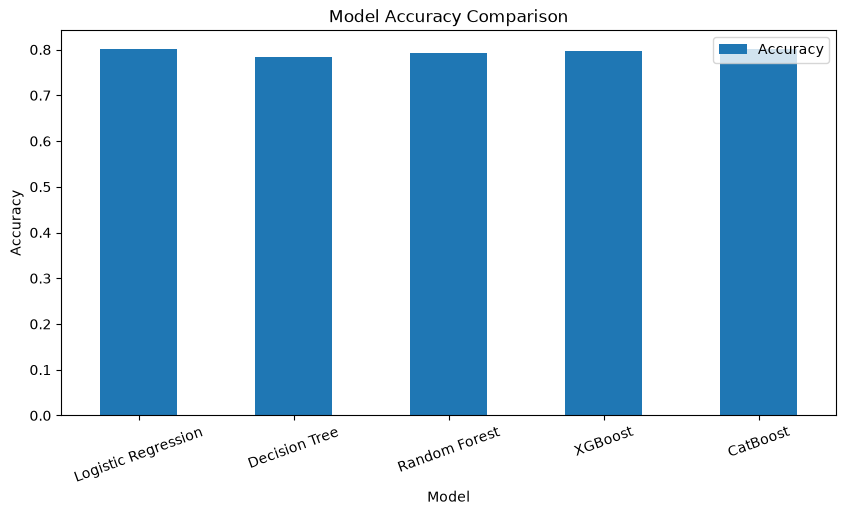

In [8]:
comparison.plot(
    x="Model",
    y="Accuracy",
    kind="bar",
    figsize=(10,5)
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=20)
plt.show()

In [9]:
comparison["Average Score"] = comparison[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC_AUC"
    ]
].mean(axis=1)

comparison.sort_values(
    "Average Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,Average Score
0,Logistic Regression,0.8010,0.6442,0.5615,0.6000,0.8350,0.68834
1,Decision Tree,0.7839,0.5862,0.6364,0.6103,0.8221,0.68778
4,CatBoost,0.8017,0.6599,0.5241,0.5842,0.8404,0.68206
3,XGBoost,0.7967,0.6477,0.5160,0.5744,0.8411,0.67518
2,Random Forest,0.7932,0.6436,0.4973,0.5611,0.8340,0.66584


## Business Interpretation

The models exhibit different strengths:

### Logistic Regression

- Highest recall among the models.
- Highly interpretable.
- Suitable when identifying as many churners as possible is the primary objective.

### Decision Tree

- Best F1 score.
- Easy to interpret.
- Slightly lower overall accuracy.

### Random Forest

- Stable performance.
- Less interpretable than a single decision tree.

### XGBoost

- Strong ROC-AUC.
- Excellent ranking capability.
- Good production candidate.

### CatBoost

- Highest accuracy.
- Highest precision.
- Competitive ROC-AUC.
- Best overall balance among all evaluated models.

# Final Model Selection

CatBoost is selected as the production model.

Reasons:

- Highest Accuracy
- Highest Precision
- Strong ROC-AUC
- Robust cross-validation performance
- Competitive F1 Score
- Good handling of categorical variables
- Suitable for structured business datasets

Although Logistic Regression achieved slightly higher recall and Decision Tree achieved the highest F1 score, CatBoost provides the most balanced overall performance and is therefore recommended for deployment.

In [10]:
comparison.to_csv(
    "../reports/model_comparison.csv",
    index=False
)

print("Comparison report saved.")

Comparison report saved.


# Conclusion

Five machine learning algorithms were evaluated for customer churn prediction.

CatBoost demonstrated the strongest overall performance and was selected as the final production model.

The next phase of the project focuses on understanding the model's predictions through explainability techniques before preparing it for deployment.